In [0]:
%pip install tensorflow keras-tuner seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.9/281.9 MB 139.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 83.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Not uninstalling protobuf at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b7ee87d3-9e86-4de0-80e6-835456a5cd02
    Can't uninstall 'protobuf'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.28.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4

In [0]:
dbutils.library.restartPython()

In [0]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")

In [0]:
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (455, 30)
Testing Data : (114, 30)


In [0]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3,5,10],
    "min_samples_split": [2,5,10,15]
}

In [0]:
print("Running Grid Search...")

model = DecisionTreeClassifier(random_state=42)

start = time.time()

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

grid_time = time.time()-start

print("Completed")

Running Grid Search...
Completed


In [0]:
results = pd.DataFrame(grid.cv_results_)

top3 = results.sort_values(
    by="mean_test_score",
    ascending=False
).head(3)

print(top3[
    [
        "params",
        "mean_test_score"
    ]
])

                                               params  mean_test_score
18  {'criterion': 'entropy', 'max_depth': 5, 'min_...         0.947253
34  {'criterion': 'log_loss', 'max_depth': 10, 'mi...         0.947253
30  {'criterion': 'log_loss', 'max_depth': 5, 'min...         0.947253


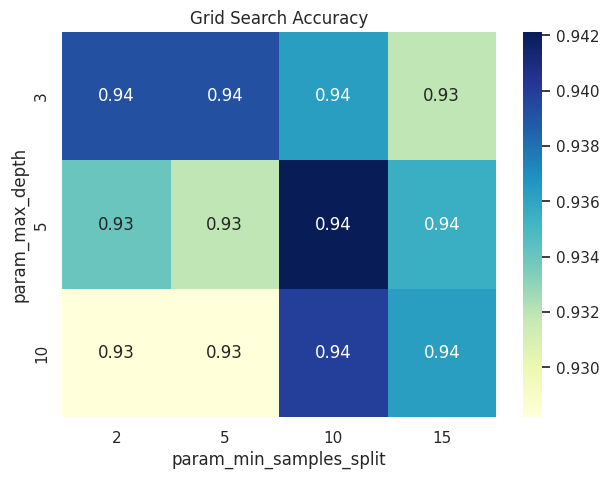

In [0]:
heatmap = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_min_samples_split"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Grid Search Accuracy")

plt.show()

In [0]:
print("Running Random Search...")

start=time.time()

random = RandomizedSearchCV(

    model,

    param_distributions=param_grid,

    n_iter=30,

    cv=5,

    scoring="accuracy",

    random_state=42

)

random.fit(X_train,y_train)

random_time=time.time()-start

print("Completed")

Running Random Search...
Completed


In [0]:
comparison = pd.DataFrame({

    "Method":[

        "Grid Search",

        "Random Search"

    ],

    "Accuracy":[

        grid.best_score_,

        random.best_score_

    ],

    "Time":[

        grid_time,

        random_time

    ]

})

print(comparison)

          Method  Accuracy      Time
0    Grid Search  0.947253  1.298707
1  Random Search  0.947253  1.177269


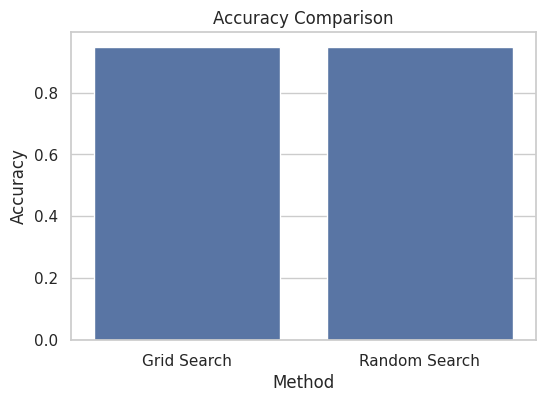

In [0]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison,

    x="Method",

    y="Accuracy"

)

plt.title("Accuracy Comparison")

plt.show()

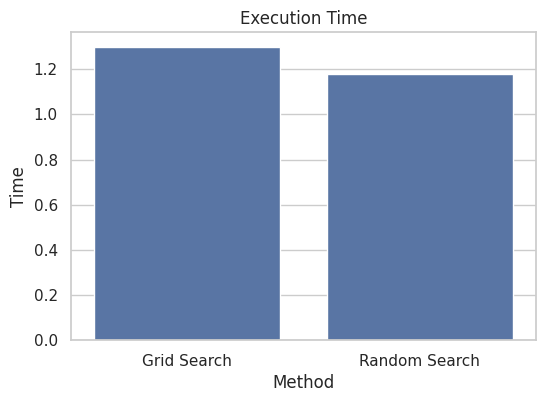

In [0]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=comparison,

    x="Method",

    y="Time"

)

plt.title("Execution Time")

plt.show()

In [0]:
import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers

import keras_tuner as kt

In [0]:
def build_model(hp):

    model=keras.Sequential([

        keras.Input(shape=(30,)),

        layers.Dense(32,activation="relu"),

        layers.Dense(1,activation="sigmoid")

    ])

    lr=hp.Choice(

        "learning_rate",

        [0.01,0.001,0.0001]

    )

    model.compile(

        optimizer=keras.optimizers.Adam(

            learning_rate=lr

        ),

        loss="binary_crossentropy",

        metrics=["accuracy"]

    )

    return model

In [0]:
%pip install tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 139.8 MB/s eta 0:00:00
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.67.0
    Not uninstalling grpcio at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b7ee87d3-9e86-4de0-80e6-835456a5cd02
    Can't uninstall 'grpcio'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.67.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.1 which is incompatible.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
tuner=kt.RandomSearch(

    build_model,

    objective="val_accuracy",

    max_trials=6,

    overwrite=True,

    directory="tuner"

)

tuner.search(

    X_train,

    y_train,

    epochs=20,

    validation_split=0.2,

    batch_size=16,

    verbose=0

)

In [0]:
best_model=grid.best_estimator_

accuracy=best_model.score(

    X_test,

    y_test

)

print("Best Parameters")

print(grid.best_params_)

print()

print("Test Accuracy")

print(accuracy)

Best Parameters
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}

Test Accuracy
0.956140350877193
